Assignment no 3. Implement a Federated Learning framework for a linear regression task where multiple clients
collaboratively learn a global prediction model without sharing their raw data. For a house price
dataset can be split across clients, each client trains a local linear regression model, and a central
server applies Federated Averaging (FedAvg) to combine the local model parameters into a
global model while preserving data privacy.

**Import Libraries**

In [17]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


**Load dataset**

In [19]:
data = pd.read_csv("/content/House Price Prediction Dataset.csv")

print(data.head())
print("Columns:", data.columns)

   Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0   1  1360         5          4       3       1970  Downtown  Excellent   
1   2  4272         5          4       3       1958  Downtown  Excellent   
2   3  3592         2          2       3       1938  Downtown       Good   
3   4   966         4          2       2       1902  Suburban       Fair   
4   5  4926         1          4       2       1975  Downtown       Fair   

  Garage   Price  
0     No  149919  
1     No  424998  
2     No  266746  
3    Yes  244020  
4    Yes  636056  
Columns: Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='object')


**Basic Cleaning,Split Features and Target,Encode Categorical Features,Convert them into num**

In [20]:
data = data.dropna()
X = data.drop("Price", axis=1)
y = data["Price"]
X = pd.get_dummies(X)
X = X.values
y = y.values.reshape(-1,1)


**Scale Features**

In [21]:
X_scaler = StandardScaler()
X = X_scaler.fit_transform(X)


**Scale Target**

In [22]:
y_scaler = StandardScaler()
y = y_scaler.fit_transform(y)


**Train-Test Split**

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


**Create Clients (From TRAIN Only)**

In [24]:
num_clients = 5

client_data = np.array_split(X_train, num_clients)
client_labels = np.array_split(y_train, num_clients)


**Initialize Global Model**

In [25]:
num_features = X_train.shape[1]

global_weights = np.zeros(num_features)
global_bias = 0


**Client Local Training Function**

In [26]:
def train_local(X, y, weights, bias, epochs=2, lr=0.001):

    weights = weights.copy()
    bias = bias
    n = len(X)

    for _ in range(epochs):

        y_pred = np.dot(X, weights) + bias

        error = y_pred.reshape(-1,1) - y

        dw = (1/n) * np.dot(X.T, error).flatten()
        db = (1/n) * np.sum(error)

        weights -= lr * dw
        bias -= lr * db

    return weights, bias, n


**FedAvg Aggregation**

In [27]:
def fedavg(client_params):

    total_samples = sum(n for _,_,n in client_params)

    new_weights = np.zeros_like(client_params[0][0])
    new_bias = 0

    for weights, bias, n in client_params:
        new_weights += weights * (n / total_samples)
        new_bias += bias * (n / total_samples)

    return new_weights, new_bias


**Federated Training Loop**

In [28]:
rounds = 40
loss_history = []

for r in range(rounds):

    client_params = []

    for i in range(num_clients):

        local_w, local_b, n = train_local(
            client_data[i],
            client_labels[i],
            global_weights,
            global_bias
        )

        client_params.append((local_w, local_b, n))

    global_weights, global_bias = fedavg(client_params)

    # Track training loss
    y_pred_train = np.dot(X_train, global_weights) + global_bias
    train_loss = np.mean((y_pred_train.reshape(-1,1) - y_train)**2)

    loss_history.append(train_loss)

    print(f"Round {r+1} | Loss: {train_loss}")


Round 1 | Loss: 0.9951751044354071
Round 2 | Loss: 0.9951288379634371
Round 3 | Loss: 0.995082783387205
Round 4 | Loss: 0.9950369397040716
Round 5 | Loss: 0.994991305916306
Round 6 | Loss: 0.994945881031062
Round 7 | Loss: 0.9949006640603523
Round 8 | Loss: 0.9948556540210248
Round 9 | Loss: 0.9948108499347381
Round 10 | Loss: 0.9947662508279356
Round 11 | Loss: 0.9947218557318237
Round 12 | Loss: 0.9946776636823452
Round 13 | Loss: 0.9946336737201575
Round 14 | Loss: 0.9945898848906072
Round 15 | Loss: 0.9945462962437065
Round 16 | Loss: 0.994502906834111
Round 17 | Loss: 0.9944597157210944
Round 18 | Loss: 0.994416721968526
Round 19 | Loss: 0.9943739246448479
Round 20 | Loss: 0.9943313228230505
Round 21 | Loss: 0.9942889155806511
Round 22 | Loss: 0.9942467019996698
Round 23 | Loss: 0.9942046811666074
Round 24 | Loss: 0.9941628521724226
Round 25 | Loss: 0.9941212141125092
Round 26 | Loss: 0.9940797660866741
Round 27 | Loss: 0.994038507199115
Round 28 | Loss: 0.9939974365583979
Round 2

**Final Evaluation (ON TEST DATA)**

In [29]:
y_pred_scaled = np.dot(X_test, global_weights) + global_bias

# Inverse scaling
y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1,1))
y_actual = y_scaler.inverse_transform(y_test)

mse = mean_squared_error(y_actual, y_pred)
r2 = r2_score(y_actual, y_pred)

print("\nFinal Results")
print("Final MSE:", mse)
print("Final R2 Score:", r2)



Final Results
Final MSE: 77797492943.46246
Final R2 Score: 1.716705074261693e-05


**Plot Training Loss**

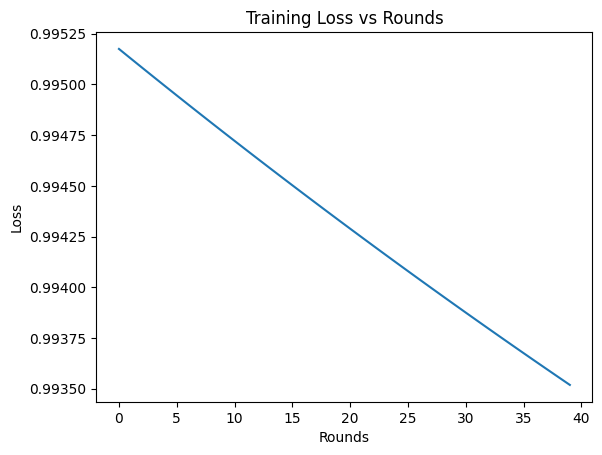

In [30]:
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.title("Training Loss vs Rounds")
plt.xlabel("Rounds")
plt.ylabel("Loss")
plt.show()
